In [1]:
'''
Ken Jinks 2026
This file contains code to produce string art from an image.
An array of 2D points represent the nails.
An average of pixel values over a line between two points gives the probability that a string should be placed. 
This is a stochatic tomographic approach.
'''

'\nKen Jinks 2026\nThis file contains code to produce string art from an image.\nAn array of 2D points represent the nails.\nAn average of pixel values over a line between two points gives the probability that a string should be placed. \nThis is a stochatic tomographic approach.\n'

In [2]:
import numpy as np
from scipy import ndimage
from PIL import Image, ImageDraw, ImageOps
import matplotlib.pyplot as plt
import time
import random

final size =  (282, 280)


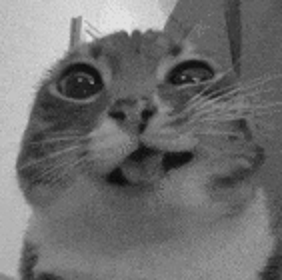

In [3]:
'''
Load image, this is the image that will be used for the string art.
'''
string_image = Image.open("./Images/cat_001.png")
ih, iw = string_image.size
string_image = string_image.resize((ih * 2, iw * 2))


print("final size = ", string_image.size)
display(string_image)


In [24]:
"""
June 2026 I asked Claude AI to produce this alogorithm. This is the prompt I used:

###I'm looking for a speedy python algorithm, possibly using the libraries pillow and numpy. 
The method will take the parameters x1, y1, x2, y2, an image and and return a colour. 
I want the method to sum all the pixels from the image in a straight line from (x1, y1) to (x2, y2) 
and return a normalized colour by dividing the sum by the number of pixels.###
"""
def sample_line_colour(x1: int, y1: int, x2: int, y2: int, image: Image.Image) -> tuple[int, int, int]:
    """
    Samples all pixels along a straight line from (x1, y1) to (x2, y2) in the
    given PIL image and returns their average as an RGB tuple.

    Parameters:
        x1, y1: Start point (column, row)
        x2, y2: End point (column, row)
        image:  A PIL Image object (any mode; converted to RGB internally)

    Returns:
        A tuple (R, G, B) with values in [0, 255].
    """
    img_array = np.asarray(image.convert("RGB"))  # H x W x 3, uint8

    num_pixels = max(abs(x2 - x1), abs(y2 - y1)) + 1

    # Bresenham-style pixel coordinates via linspace (vectorised, no Python loop)
    xs = np.round(np.linspace(x1, x2, num_pixels)).astype(np.intp)
    ys = np.round(np.linspace(y1, y2, num_pixels)).astype(np.intp)

    # Clamp to image bounds so out-of-range endpoints don't raise an IndexError
    h, w = img_array.shape[:2]
    xs = np.clip(xs, 0, w - 1)
    ys = np.clip(ys, 0, h - 1)

    # Fancy-index all pixels at once, then average (stays in float until the end)
    pixels = img_array[ys, xs]          # shape: (num_pixels, 3)
    avg = np.median(pixels, axis=0)           # shape: (3,)

    return tuple(np.round(avg).astype(np.uint8).tolist())

In [18]:
# --- quick smoke-test ---
if __name__ == "__main__":
    # Solid red 100x100 image → should return (255, 0, 0)
    red = Image.new("RGB", (100, 100), (255, 0, 0))
    print(sample_line_colour(0, 0, 99, 99, red))   # (255, 0, 0)

    # Gradient: left half blue, right half green → diagonal avg ≈ (0, 127, 127)
    gradient = Image.new("RGB", (100, 100), (0, 0, 255))
    right_half = Image.new("RGB", (50, 100), (0, 255, 0))
    gradient.paste(right_half, (50, 0))
    print(sample_line_colour(0, 50, 99, 50, gradient))  # ≈ (0, 127, 127)

AttributeError: 'numpy.ndarray' object has no attribute 'median'

In [19]:
'''
Before we start stringing, we need a list of nail positions.
I am going to take the FFT of the given image and use the 
frequency distribution to determine the likelihood of a nail.
The image is divided into cells and each cell's fft is binned by indexing
each pixel in the fft by it's radius from center which give the frequency distrbution in that cell.
Then weight high if most of the energy is in the high frequencies, low in the lower frequencies and colour that pixel.

This has since been replaced with a sobel filter and gaussian blur.

final_fft = string_image.convert("L")
copy_image = string_image.convert("L")

width, height = copy_image.size
num_cells_across = 10
cell_size = int(width/num_cells_across) #the side length of the square cells to be sampled (window size)

#ImageOps.expand(copy_image, border=cell_size, fill="#000000")



draw_fft = ImageDraw.Draw(final_fft)

time_start = time.time()
#step through each cell and calc the fft then use that to derive a value to represent the frequency 
#distribution which will lead to the probability of a nail
for xoff in range(cell_size):
    for yoff in range(cell_size):
        for x in range(width//cell_size):
            for y in range(height//cell_size):
                xpos = (x * cell_size) + xoff;
                ypos = (y * cell_size) + yoff;
        
                cropped_image = copy_image.crop((xpos, ypos, xpos + cell_size, ypos + cell_size))
                #get the fft of the cell
                cell_array = np.array(cropped_image)
        
                fft = np.fft.fft2(cell_array)
                fft_shifted = np.fft.fftshift(fft)
                
                #created a weighted sum by radius of the fft to find frequency distribution 
                #and discard angular information
                power = np.abs(fft_shifted) ** 2
                
                h, w = power.shape
                cy, cx = h // 2, w // 2
                
                # distance of each pixel from center
                yd, xd = np.indices((h, w))
                r = np.sqrt((xd - cx)**2 + (yd - cy)**2).astype(int)
                
                # sum power in each radial bin, then average
                radial_sum = np.bincount(r.ravel(), weights=power.ravel())
                radial_count = np.bincount(r.ravel())
                radial_profile = radial_sum / radial_count
                
                frequencies = np.arange(len(radial_profile))
                centroid = np.sum(frequencies * radial_profile) / np.sum(radial_profile)
                normalized_centroid = centroid / (len(radial_profile) - 1) 
                
                gamma = 0.25
                fill_colour = int((normalized_centroid**gamma) * 255)
                draw_fft.point((xpos, ypos), fill=fill_colour)
        
time_end = time.time()
print("Time: ", (time_end-time_start), " seconds")
display(final_fft)
'''

'\nBefore we start stringing, we need a list of nail positions.\nI am going to take the FFT of the given image and use the \nfrequency distribution to determine the likelihood of a nail.\nThe image is divided into cells and each cell\'s fft is binned by indexing\neach pixel in the fft by it\'s radius from center which give the frequency distrbution in that cell.\nThen weight high if most of the energy is in the high frequencies, low in the lower frequencies and colour that pixel.\n\nThis has since been replaced with a sobel filter and gaussian blur.\n\nfinal_fft = string_image.convert("L")\ncopy_image = string_image.convert("L")\n\nwidth, height = copy_image.size\nnum_cells_across = 10\ncell_size = int(width/num_cells_across) #the side length of the square cells to be sampled (window size)\n\n#ImageOps.expand(copy_image, border=cell_size, fill="#000000")\n\n\n\ndraw_fft = ImageDraw.Draw(final_fft)\n\ntime_start = time.time()\n#step through each cell and calc the fft then use that to de

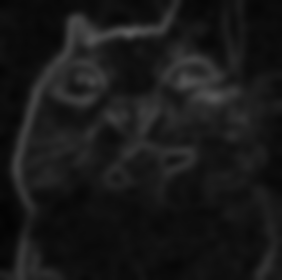

In [20]:
'''
It was later I realized a sobel filter would do a similar job
'''
arr = np.array(string_image.convert('L'), dtype=float)

sx = ndimage.sobel(arr, axis=0)
sy = ndimage.sobel(arr, axis=1)
mag = np.hypot(sx, sy)
mag = (mag / mag.max() * 255).astype(np.uint8)

blurred_mag = ndimage.gaussian_filter(mag, sigma=4)
final_fft = Image.fromarray(blurred_mag)
display(final_fft)

The distribution of pins.


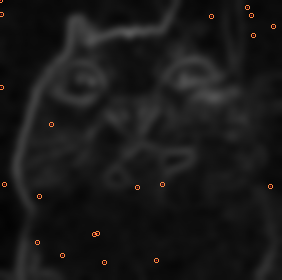

In [21]:
'''
Using the generated image above as a heat map of probabilities, 
add a fixed number of pins using those probabilities.
'''
pin_image = final_fft.convert("RGB")
draw_image = ImageDraw.Draw(pin_image)

width, height = final_fft.size

max_pins = 20
pins = []

current_pin = 0
gamma= 1.5
random.seed(float(time.time()))
while(current_pin < max_pins):
    rw = random.randint(0, width - 1)
    rh = random.randint(0, height - 1)
    sample = final_fft.getpixel((rw, rh)) ** gamma

    if ((sample/255) < random.random()):
        current_pin = current_pin + 1
        draw_image.point((rw, rh), fill="#FF0000")
        draw_image.ellipse([(rw-2, rh-2), (rw+2, rh+2)], outline="#FF8844")
        pins.append((rw, rh))
print("The distribution of pins.")
display(pin_image)

In [22]:
'''
Make a circle of pins
'''
width, height = string_image.size

half_width = width//2
half_height = height//2

num_points = 100

angles = np.linspace(0, 2 * np.pi, num_points, endpoint=False)
xs = (half_width + half_width * np.cos(angles)).astype(int)
ys = (half_height + half_width * np.sin(angles)).astype(int)
pins = list(zip(xs, ys))

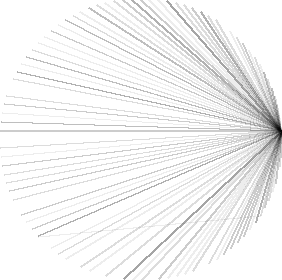

In [26]:
sample_image = string_image.convert("L")
final_string_image = string_image.convert("RGB")
string_width = 2
sample_image_draw = ImageDraw.Draw(final_string_image , "RGBA")
sample_image_draw.rectangle((0,0,final_string_image.width, final_string_image.height), fill="#ffffffff")
string_colour = "#00000012"

max_strings = 200

random.seed(float(time.time()))

pin_start = random.sample(pins, 1)
pin_current = pin_start[0]

max_samples = 100
pin_index = -1

for st in range(max_strings):
    pin_sample = random.sample(pins, max_samples)


    last_string_probability = -1
    
    for sam in range(max_samples):
        pin_test = pin_sample[sam]
        
        string_probability = sample_line_colour(pin_current[0], pin_current[1], pin_test[0], pin_test[1], sample_image)[0]
        
        if (string_probability < last_string_probability):
            last_string_probability = string_probability
            pin_index = sam
    
    
    sample_image_draw.line((pin_current, pin_sample[pin_index]), fill=string_colour, width=string_width)
    pin_current = pins[pin_index]

    
display(final_string_image )